# 03 Model Training
## ML Role
Model training pipeline for validated models with cross-validation.
Implements data splitting protocols (88/8.8/2.9 Train/Val/Test), training isolated validation algorithms (decision tree, xgb, rf, svm, etc.), evaluating temporal losses, generating hyperparameter matrices.\n

In [3]:
# Cell 1: Imports & Setup
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import pickle

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Output directories
os.makedirs('outputs/models', exist_ok=True)
os.makedirs('outputs/plots', exist_ok=True)
os.makedirs('outputs/metrics', exist_ok=True)

print("=" * 70)
print("MODEL TRAINING NOTEBOOK - ENERGY CONSUMPTION & PRICE PREDICTION")
print("=" * 70)
print(f"TensorFlow version: {tf.__version__}")
print(f"XGBoost version: {xgb.__version__}")
print("✓ All libraries loaded successfully")

MODEL TRAINING NOTEBOOK - ENERGY CONSUMPTION & PRICE PREDICTION
TensorFlow version: 2.10.0
XGBoost version: 2.0.3
✓ All libraries loaded successfully


In [10]:
!python test.py

Python Version: 3.10.4 (tags/v3.10.4:9d38120, Mar 23 2022, 23:13:41) [MSC v.1929 64 bit (AMD64)]
PyTorch Version: 2.5.1+cu121
Is CUDA available? True
GPU Device: NVIDIA GeForce RTX 3060 Laptop GPU
VRAM Available: 6.44 GB


In [4]:
# Cell 2: Load Feature Data
print("=" * 70)
print("LOADING FEATURE ENGINEERED DATA")
print("=" * 70)

train_df = pd.read_csv('data/features/spain_features_train.csv', index_col=0, parse_dates=True)
val_df   = pd.read_csv('data/features/spain_features_val.csv',   index_col=0, parse_dates=True)
test_df  = pd.read_csv('data/features/spain_features_test.csv',  index_col=0, parse_dates=True)

print(f"✓ Train shape : {train_df.shape}")
print(f"✓ Val shape   : {val_df.shape}")
print(f"✓ Test shape  : {test_df.shape}")
print(f"\nDate range:")
print(f"  Train : {train_df.index.min()} → {train_df.index.max()}")
print(f"  Val   : {val_df.index.min()}   → {val_df.index.max()}")
print(f"  Test  : {test_df.index.min()}  → {test_df.index.max()}")
print(f"\nColumns preview: {list(train_df.columns[:10])} ...")

LOADING FEATURE ENGINEERED DATA
✓ Train shape : (87311, 130)
✓ Val shape   : (8730, 130)
✓ Test shape  : (2412, 130)

Date range:
  Train : 2015-01-08 02:00:00 → 2024-12-31 23:00:00
  Val   : 2025-01-01 00:00:00   → 2025-12-31 23:00:00
  Test  : 2026-01-01 00:00:00  → 2026-04-12 21:00:00

Columns preview: ['consumption_mw', 'price_eur_mwh', 'load_forecast_mw', 'price_day_ahead_eur', 'gen_solar_mw', 'gen_wind_onshore_mw', 'gen_wind_offshore_mw', 'gen_hydro_ror_mw', 'gen_nuclear_mw', 'gen_fossil_gas_mw'] ...


In [5]:
import pandas as pd
df = pd.read_csv('data/features/spain_features_train.csv', index_col=0, nrows=2)
print(df.columns.tolist())

['consumption_mw', 'price_eur_mwh', 'load_forecast_mw', 'price_day_ahead_eur', 'gen_solar_mw', 'gen_wind_onshore_mw', 'gen_wind_offshore_mw', 'gen_hydro_ror_mw', 'gen_nuclear_mw', 'gen_fossil_gas_mw', 'forecast_solar_mw', 'forecast_wind_onshore_mw', 'temperature_celsius', 'temp_min_celsius', 'temp_max_celsius', 'pressure_hpa', 'humidity_percent', 'wind_speed_ms', 'wind_direction_deg', 'rain_mm', 'cloud_cover_percent', 'year', 'month', 'day', 'hour', 'dayofweek', 'is_weekend', 'quarter', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'consumption_lag_1h', 'consumption_lag_2h', 'consumption_lag_3h', 'consumption_lag_6h', 'consumption_lag_12h', 'consumption_lag_24h', 'consumption_lag_48h', 'consumption_lag_168h', 'price_lag_1h', 'price_lag_2h', 'price_lag_3h', 'price_lag_6h', 'price_lag_12h', 'price_lag_24h', 'price_lag_48h', 'price_lag_168h', 'temp_lag_1h', 'temp_lag_24h', 'consumption_rolling_mean_24h', 'consumption_rolling_std_24h', 'consumption_rolling_min_24h', 'consumption_rollin

In [6]:
# Cell 3: Define Targets & Feature Columns
print("=" * 70)
print("DEFINING TARGETS AND FEATURE COLUMNS")
print("=" * 70)
 
# ── 24-hour multi-output targets ──
CONSUMPTION_TARGETS = [f'target_consumption_h{i}' for i in range(1, 25)]  # 24 columns
PRICE_TARGETS       = [f'target_price_h{i}'       for i in range(1, 25)]  # 24 columns
 
# ── Single-step targets (for LSTM) ──
CONSUMPTION_TARGET = 'consumption_mw'
PRICE_TARGET       = 'price_eur_mwh'
 
# ── Feature columns: exclude all target columns ──
ALL_TARGET_COLS = CONSUMPTION_TARGETS + PRICE_TARGETS
FEATURE_COLS = [col for col in train_df.columns if col not in ALL_TARGET_COLS]
 
print(f"✓ Feature columns       : {len(FEATURE_COLS)}")
print(f"✓ Consumption targets   : {len(CONSUMPTION_TARGETS)} (h1 to h24)")
print(f"✓ Price targets         : {len(PRICE_TARGETS)} (h1 to h24)")
 
# ── Split X and y ──
X_train = train_df[FEATURE_COLS].values
X_val   = val_df[FEATURE_COLS].values
X_test  = test_df[FEATURE_COLS].values
 
# Multi-output (for Linear Regression & XGBoost)
y_train_cons  = train_df[CONSUMPTION_TARGETS].values   # shape: (n, 24)
y_val_cons    = val_df[CONSUMPTION_TARGETS].values
y_test_cons   = test_df[CONSUMPTION_TARGETS].values
 
y_train_price = train_df[PRICE_TARGETS].values         # shape: (n, 24)
y_val_price   = val_df[PRICE_TARGETS].values
y_test_price  = test_df[PRICE_TARGETS].values
 
# Single-step targets (for LSTM sequences)
y_train_cons_1h  = train_df[CONSUMPTION_TARGET].values
y_val_cons_1h    = val_df[CONSUMPTION_TARGET].values
y_test_cons_1h   = test_df[CONSUMPTION_TARGET].values
 
y_train_price_1h = train_df[PRICE_TARGET].values
y_val_price_1h   = val_df[PRICE_TARGET].values
y_test_price_1h  = test_df[PRICE_TARGET].values
 
print(f"\n✓ X_train shape : {X_train.shape}")
print(f"✓ y_train_cons  : {y_train_cons.shape}  ← 24 output columns")
print(f"✓ y_train_price : {y_train_price.shape}  ← 24 output columns")
# ── Handle Infinity & Large Values ──
from sklearn.impute import SimpleImputer

print("\n🔍 Data Validation...")
print(f"   Infinities in X_train: {np.sum(np.isinf(X_train))}")
print(f"   NaNs in X_train: {np.sum(np.isnan(X_train))}")

# Replace infinity values with NaN
X_train = np.where(np.isinf(X_train), np.nan, X_train)
X_val   = np.where(np.isinf(X_val),   np.nan, X_val)
X_test  = np.where(np.isinf(X_test),  np.nan, X_test)

# Clip to 99.9th percentile to remove extreme outliers
valid_mask = ~np.isnan(X_train)
if np.any(valid_mask):
    max_val = np.nanpercentile(X_train, 99.9)
    min_val = np.nanpercentile(X_train, 0.1)
    X_train = np.clip(X_train, min_val, max_val)
    X_val   = np.clip(X_val,   min_val, max_val)
    X_test  = np.clip(X_test,  min_val, max_val)
    print(f"   Clipped to range [{min_val:.2e}, {max_val:.2e}]")

# Now safely impute NaNs
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_val   = imputer.transform(X_val)
X_test  = imputer.transform(X_test)

y_train_cons  = pd.DataFrame(y_train_cons).fillna(method='ffill').values
y_val_cons    = pd.DataFrame(y_val_cons).fillna(method='ffill').values
y_test_cons   = pd.DataFrame(y_test_cons).fillna(method='ffill').values
y_train_price = pd.DataFrame(y_train_price).fillna(method='ffill').values
y_val_price   = pd.DataFrame(y_val_price).fillna(method='ffill').values
y_test_price  = pd.DataFrame(y_test_price).fillna(method='ffill').values

print("✓ Data validation & imputation complete")
print("✓ Cell 3 complete — ready for model training")

DEFINING TARGETS AND FEATURE COLUMNS
✓ Feature columns       : 82
✓ Consumption targets   : 24 (h1 to h24)
✓ Price targets         : 24 (h1 to h24)

✓ X_train shape : (87311, 82)
✓ y_train_cons  : (87311, 24)  ← 24 output columns
✓ y_train_price : (87311, 24)  ← 24 output columns

🔍 Data Validation...
   Infinities in X_train: 463
   NaNs in X_train: 0
   Clipped to range [-3.81e+03, 3.82e+04]
✓ Data validation & imputation complete
✓ Cell 3 complete — ready for model training


In [7]:
# Cell 4: Baseline — Multi-Output Linear Regression
print("=" * 70)
print("BASELINE MODEL: MULTI-OUTPUT LINEAR REGRESSION")
print("=" * 70)

from sklearn.multioutput import MultiOutputRegressor

def mape(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

results = {}

# ── Consumption ──
lr_cons = LinearRegression()
lr_cons.fit(X_train, y_train_cons)
pred_lr_cons = lr_cons.predict(X_test)   # shape: (n_test, 24)

results['LR_Consumption'] = {
    'RMSE' : np.sqrt(mean_squared_error(y_test_cons, pred_lr_cons)),
    'MAE'  : mean_absolute_error(y_test_cons, pred_lr_cons),
    'MAPE' : mape(y_test_cons.ravel(), pred_lr_cons.ravel()),
    'R2'   : r2_score(y_test_cons, pred_lr_cons)
}
print(f"✓ LR Consumption  → RMSE: {results['LR_Consumption']['RMSE']:.2f} | MAPE: {results['LR_Consumption']['MAPE']:.2f}% | R²: {results['LR_Consumption']['R2']:.4f}")

# ── Price ──
lr_price = LinearRegression()
lr_price.fit(X_train, y_train_price)
pred_lr_price = lr_price.predict(X_test)

results['LR_Price'] = {
    'RMSE' : np.sqrt(mean_squared_error(y_test_price, pred_lr_price)),
    'MAE'  : mean_absolute_error(y_test_price, pred_lr_price),
    'MAPE' : mape(y_test_price.ravel(), pred_lr_price.ravel()),
    'R2'   : r2_score(y_test_price, pred_lr_price)
}
print(f"✓ LR Price        → RMSE: {results['LR_Price']['RMSE']:.2f} | MAPE: {results['LR_Price']['MAPE']:.2f}% | R²: {results['LR_Price']['R2']:.4f}")

pickle.dump(lr_cons,  open('outputs/models/lr_consumption.pkl', 'wb'))
pickle.dump(lr_price, open('outputs/models/lr_price.pkl',      'wb'))
print("\n✓ Baseline models saved")

BASELINE MODEL: MULTI-OUTPUT LINEAR REGRESSION
✓ LR Consumption  → RMSE: 2720.51 | MAPE: 6.38% | R²: 0.7007
✓ LR Price        → RMSE: 25.71 | MAPE: 5859.34% | R²: 0.6825

✓ Baseline models saved


In [8]:
# Cell 5: XGBoost — Consumption (Multi-Output)
print("=" * 70)
print("XGBOOST: ENERGY CONSUMPTION (24-hour multi-output)")
print("=" * 70)

from sklearn.multioutput import MultiOutputRegressor

xgb_base_cons = xgb.XGBRegressor(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 7,
    min_child_weight = 3,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = 42,
    n_jobs           = -1,
)

xgb_cons = MultiOutputRegressor(xgb_base_cons, n_jobs=-1)
xgb_cons.fit(X_train, y_train_cons)
pred_xgb_cons = xgb_cons.predict(X_test)   # shape: (n_test, 24)

results['XGB_Consumption'] = {
    'RMSE' : np.sqrt(mean_squared_error(y_test_cons, pred_xgb_cons)),
    'MAE'  : mean_absolute_error(y_test_cons, pred_xgb_cons),
    'MAPE' : mape(y_test_cons.ravel(), pred_xgb_cons.ravel()),
    'R2'   : r2_score(y_test_cons, pred_xgb_cons)
}
print(f"✓ XGBoost Consumption → RMSE: {results['XGB_Consumption']['RMSE']:.2f} | MAPE: {results['XGB_Consumption']['MAPE']:.2f}% | R²: {results['XGB_Consumption']['R2']:.4f}")

# Feature importance from first estimator (h1)
feat_imp_cons = pd.Series(
    xgb_cons.estimators_[0].feature_importances_,
    index=FEATURE_COLS
).nlargest(20)

print(f"\n🔝 Top 5 features (consumption h1):")
for f, s in feat_imp_cons.head(5).items():
    print(f"   {f}: {s:.4f}")

pickle.dump(xgb_cons, open('outputs/models/xgb_consumption.pkl', 'wb'))
print("\n✓ XGBoost Consumption model saved")

XGBOOST: ENERGY CONSUMPTION (24-hour multi-output)
✓ XGBoost Consumption → RMSE: 1729.24 | MAPE: 3.21% | R²: 0.8791

🔝 Top 5 features (consumption h1):
   load_forecast_mw: 0.3408
   consumption_mw: 0.3044
   consumption_lag_1h: 0.1282
   consumption_lag_24h: 0.0615
   consumption_diff_24h: 0.0246

✓ XGBoost Consumption model saved


In [15]:
# Cell 5B: Decision Tree & Random Forest - Both targets
print("=" * 70)
print("DECISION TREE & RANDOM FOREST - CONSUMPTION & PRICE")
print("=" * 70)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

# ── Decision Tree ──
print("\n[1/4] Training Decision Tree - Consumption...")
dt_cons = MultiOutputRegressor(
    DecisionTreeRegressor(
        max_depth        = 12,
        min_samples_split= 10,
        min_samples_leaf = 5,
        random_state     = 42
    ), n_jobs=-1
)
dt_cons.fit(X_train, y_train_cons)
pred_dt_cons = dt_cons.predict(X_test)

results['DT_Consumption'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test_cons,  pred_dt_cons)),
    'MAE' : mean_absolute_error(y_test_cons,          pred_dt_cons),
    'MAPE': mape(y_test_cons.ravel(),                 pred_dt_cons.ravel()),
    'R2'  : r2_score(y_test_cons,                     pred_dt_cons)
}
print(f"✓ DT Consumption  → RMSE: {results['DT_Consumption']['RMSE']:.2f} | "
      f"MAPE: {results['DT_Consumption']['MAPE']:.2f}% | "
      f"R²: {results['DT_Consumption']['R2']:.4f}")

print("\n[2/4] Training Decision Tree - Price...")
dt_price = MultiOutputRegressor(
    DecisionTreeRegressor(
        max_depth        = 10,
        min_samples_split= 15,
        min_samples_leaf = 8,
        random_state     = 42
    ), n_jobs=-1
)
dt_price.fit(X_train, y_train_price)
pred_dt_price = dt_price.predict(X_test)

results['DT_Price'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test_price,  pred_dt_price)),
    'MAE' : mean_absolute_error(y_test_price,          pred_dt_price),
    'MAPE': mape(y_test_price.ravel(),                 pred_dt_price.ravel()),
    'R2'  : r2_score(y_test_price,                     pred_dt_price)
}
print(f"✓ DT Price        → RMSE: {results['DT_Price']['RMSE']:.2f} | "
      f"MAPE: {results['DT_Price']['MAPE']:.2f}% | "
      f"R²: {results['DT_Price']['R2']:.4f}")

print("\n[3/4] Training Random Forest - Consumption...")
rf_cons = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators     = 200,
        max_depth        = 15,
        min_samples_split= 5,
        min_samples_leaf = 3,
        max_features     = 'sqrt',
        random_state     = 42,
        n_jobs           = -1
    ), n_jobs=-1
)
rf_cons.fit(X_train, y_train_cons)
pred_rf_cons = rf_cons.predict(X_test)

results['RF_Consumption'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test_cons,  pred_rf_cons)),
    'MAE' : mean_absolute_error(y_test_cons,          pred_rf_cons),
    'MAPE': mape(y_test_cons.ravel(),                 pred_rf_cons.ravel()),
    'R2'  : r2_score(y_test_cons,                     pred_rf_cons)
}
print(f"✓ RF Consumption  → RMSE: {results['RF_Consumption']['RMSE']:.2f} | "
      f"MAPE: {results['RF_Consumption']['MAPE']:.2f}% | "
      f"R²: {results['RF_Consumption']['R2']:.4f}")

print("\n[4/4] Training Random Forest - Price...")
rf_price = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators     = 200,
        max_depth        = 12,
        min_samples_split= 8,
        min_samples_leaf = 5,
        max_features     = 'sqrt',
        random_state     = 42,
        n_jobs           = -1
    ), n_jobs=-1
)
rf_price.fit(X_train, y_train_price)
pred_rf_price = rf_price.predict(X_test)

results['RF_Price'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test_price,  pred_rf_price)),
    'MAE' : mean_absolute_error(y_test_price,          pred_rf_price),
    'MAPE': mape(y_test_price.ravel(),                 pred_rf_price.ravel()),
    'R2'  : r2_score(y_test_price,                     pred_rf_price)
}
print(f"✓ RF Price        → RMSE: {results['RF_Price']['RMSE']:.2f} | "
      f"MAPE: {results['RF_Price']['MAPE']:.2f}% | "
      f"R²: {results['RF_Price']['R2']:.4f}")

# Save all
pickle.dump(dt_cons,  open('outputs/models/dt_consumption.pkl',  'wb'))
pickle.dump(dt_price, open('outputs/models/dt_price.pkl',        'wb'))
pickle.dump(rf_cons,  open('outputs/models/rf_consumption.pkl',  'wb'))
pickle.dump(rf_price, open('outputs/models/rf_price.pkl',        'wb'))
print("\n✓ DT and RF models saved")

DECISION TREE & RANDOM FOREST - CONSUMPTION & PRICE

[1/4] Training Decision Tree - Consumption...
✓ DT Consumption  → RMSE: 2269.09 | MAPE: 4.71% | R²: 0.7917

[2/4] Training Decision Tree - Price...
✓ DT Price        → RMSE: 31.32 | MAPE: 8536.32% | R²: 0.5290

[3/4] Training Random Forest - Consumption...
✓ RF Consumption  → RMSE: 1950.46 | MAPE: 3.97% | R²: 0.8461

[4/4] Training Random Forest - Price...
✓ RF Price        → RMSE: 26.77 | MAPE: 9081.69% | R²: 0.6559

✓ DT and RF models saved


In [ ]:
# Cell 5C: SVM - Consumption & Price
print("=" * 70)
print("SVM (LinearSVR) - CONSUMPTION & PRICE")
print("=" * 70)

from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler

# SVM needs StandardScaler (not MinMax) and works best on smaller samples
# We use LinearSVR — scales to large data unlike kernel SVM
print("Note: Using LinearSVR (scales to large datasets)")
print("      SVM needs StandardScaled features separately from XGBoost scaler\n")

# Scale specifically for SVM
svm_scaler_X = StandardScaler()
X_train_svm  = svm_scaler_X.fit_transform(X_train)
X_test_svm   = svm_scaler_X.transform(X_test)

# ── SVM Consumption ──
print("[1/2] Training SVM - Consumption (this may take 5-10 min)...")
svm_cons = MultiOutputRegressor(
    LinearSVR(
        C              = 1.0,
        epsilon        = 0.1,
        max_iter       = 2000,
        random_state   = 42
    ), n_jobs=-1
)
svm_cons.fit(X_train_svm, y_train_cons)
pred_svm_cons = svm_cons.predict(X_test_svm)

results['SVM_Consumption'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test_cons,  pred_svm_cons)),
    'MAE' : mean_absolute_error(y_test_cons,          pred_svm_cons),
    'MAPE': mape(y_test_cons.ravel(),                 pred_svm_cons.ravel()),
    'R2'  : r2_score(y_test_cons,                     pred_svm_cons)
}
print(f"✓ SVM Consumption → RMSE: {results['SVM_Consumption']['RMSE']:.2f} | "
      f"MAPE: {results['SVM_Consumption']['MAPE']:.2f}% | "
      f"R²: {results['SVM_Consumption']['R2']:.4f}")

# ── SVM Price ──
print("\n[2/2] Training SVM - Price...")
svm_price = MultiOutputRegressor(
    LinearSVR(
        C              = 1.0,
        epsilon        = 0.05,
        max_iter       = 2000,
        random_state   = 42
    ), n_jobs=-1
)
svm_price.fit(X_train_svm, y_train_price)
pred_svm_price = svm_price.predict(X_test_svm)

results['SVM_Price'] = {
    'RMSE': np.sqrt(mean_squared_error(y_test_price,  pred_svm_price)),
    'MAE' : mean_absolute_error(y_test_price,          pred_svm_price),
    'MAPE': mape(y_test_price.ravel(),                 pred_svm_price.ravel()),
    'R2'  : r2_score(y_test_price,                     pred_svm_price)
}
print(f"✓ SVM Price       → RMSE: {results['SVM_Price']['RMSE']:.2f} | "
      f"MAPE: {results['SVM_Price']['MAPE']:.2f}% | "
      f"R²: {results['SVM_Price']['R2']:.4f}")

# Save
pickle.dump(svm_cons,     open('outputs/models/svm_consumption.pkl', 'wb'))
pickle.dump(svm_price,    open('outputs/models/svm_price.pkl',       'wb'))
pickle.dump(svm_scaler_X, open('outputs/models/svm_scaler_X.pkl',    'wb'))
print("\n✓ SVM models + SVM scaler saved")

SVM (LinearSVR) - CONSUMPTION & PRICE
Note: Using LinearSVR (scales to large datasets)
      SVM needs StandardScaled features separately from XGBoost scaler

[1/2] Training SVM - Consumption (this may take 5-10 min)...
✓ SVM Consumption → RMSE: 2820.38 | MAPE: 6.31% | R²: 0.6783

[2/2] Training SVM - Price...
✓ SVM Price       → RMSE: 25.92 | MAPE: 5285.47% | R²: 0.6772

✓ SVM models + SVM scaler saved


In [17]:
# Cell 6: XGBoost — Price (Multi-Output)
print("=" * 70)
print("XGBOOST: ENERGY PRICE (24-hour multi-output)")
print("=" * 70)

xgb_base_price = xgb.XGBRegressor(
    n_estimators     = 500,
    learning_rate    = 0.05,
    max_depth        = 6,
    min_child_weight = 5,
    subsample        = 0.75,
    colsample_bytree = 0.75,
    reg_alpha        = 0.5,
    reg_lambda       = 1.5,
    random_state     = 42,
    n_jobs           = -1,
)

xgb_price = MultiOutputRegressor(xgb_base_price, n_jobs=-1)
xgb_price.fit(X_train, y_train_price)
pred_xgb_price = xgb_price.predict(X_test)

results['XGB_Price'] = {
    'RMSE' : np.sqrt(mean_squared_error(y_test_price, pred_xgb_price)),
    'MAE'  : mean_absolute_error(y_test_price, pred_xgb_price),
    'MAPE' : mape(y_test_price.ravel(), pred_xgb_price.ravel()),
    'R2'   : r2_score(y_test_price, pred_xgb_price)
}
print(f"✓ XGBoost Price → RMSE: {results['XGB_Price']['RMSE']:.2f} | MAPE: {results['XGB_Price']['MAPE']:.2f}% | R²: {results['XGB_Price']['R2']:.4f}")

feat_imp_price = pd.Series(
    xgb_price.estimators_[0].feature_importances_,
    index=FEATURE_COLS
).nlargest(20)

print(f"\n🔝 Top 5 features (price h1):")
for f, s in feat_imp_price.head(5).items():
    print(f"   {f}: {s:.4f}")

pickle.dump(xgb_price, open('outputs/models/xgb_price.pkl', 'wb'))
print("\n✓ XGBoost Price model saved")

XGBOOST: ENERGY PRICE (24-hour multi-output)
✓ XGBoost Price → RMSE: 25.38 | MAPE: 6791.89% | R²: 0.6906

🔝 Top 5 features (price h1):
   price_eur_mwh: 0.5398
   price_day_ahead_eur: 0.3594
   price_lag_1h: 0.0274
   price_rolling_mean_24h: 0.0128
   day_sin: 0.0109

✓ XGBoost Price model saved


In [9]:
# Cell 7: LSTM Data Preparation (sequence → 24-step output)
print("=" * 70)
print("LSTM DATA PREPARATION (seq → 24-step output)")
print("=" * 70)

from sklearn.preprocessing import MinMaxScaler

LOOKBACK = 48  # Use past 48 hours as input sequence

scaler_X     = MinMaxScaler()
scaler_cons  = MinMaxScaler()
scaler_price = MinMaxScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_val_sc   = scaler_X.transform(X_val)
X_test_sc  = scaler_X.transform(X_test)

# Scale the 24 target columns together
y_train_cons_sc  = scaler_cons.fit_transform(y_train_cons)    # (n, 24)
y_val_cons_sc    = scaler_cons.transform(y_val_cons)
y_test_cons_sc   = scaler_cons.transform(y_test_cons)

y_train_price_sc = scaler_price.fit_transform(y_train_price)
y_val_price_sc   = scaler_price.transform(y_val_price)
y_test_price_sc  = scaler_price.transform(y_test_price)

def create_sequences_multi(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])   # (lookback, n_features)
        ys.append(y[i])              # (24,)
    return np.array(Xs), np.array(ys)

X_tr_cons,  y_tr_cons  = create_sequences_multi(X_train_sc, y_train_cons_sc,  LOOKBACK)
X_vl_cons,  y_vl_cons  = create_sequences_multi(X_val_sc,   y_val_cons_sc,    LOOKBACK)
X_te_cons,  y_te_cons  = create_sequences_multi(X_test_sc,  y_test_cons_sc,   LOOKBACK)

X_tr_price, y_tr_price = create_sequences_multi(X_train_sc, y_train_price_sc, LOOKBACK)
X_vl_price, y_vl_price = create_sequences_multi(X_val_sc,   y_val_price_sc,   LOOKBACK)
X_te_price, y_te_price = create_sequences_multi(X_test_sc,  y_test_price_sc,  LOOKBACK)

print(f"✓ LSTM input  shape : {X_tr_cons.shape}   ← (samples, 48h lookback, features)")
print(f"✓ LSTM output shape : {y_tr_cons.shape}  ← (samples, 24h ahead)")

pickle.dump(scaler_X,     open('outputs/models/scaler_X.pkl',     'wb'))
pickle.dump(scaler_cons,  open('outputs/models/scaler_cons.pkl',  'wb'))
pickle.dump(scaler_price, open('outputs/models/scaler_price.pkl', 'wb'))
print("✓ Scalers saved")

LSTM DATA PREPARATION (seq → 24-step output)
✓ LSTM input  shape : (87263, 48, 82)   ← (samples, 48h lookback, features)
✓ LSTM output shape : (87263, 24)  ← (samples, 24h ahead)
✓ Scalers saved


In [10]:
# =========================================================
# PYTORCH LSTM - GPU OPTIMIZED (STABLE VERSION)
# =========================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# -------------------------------
# 1. DEVICE SETUP
# -------------------------------
DEVICE = torch.device('cuda')
print("Using GPU:", torch.cuda.get_device_name(0))

torch.backends.cudnn.benchmark = True  # speed boost

# -------------------------------
# 2. DATA LOADER (CPU → GPU per batch)
# -------------------------------
def make_loader(X, y, batch_size=32, shuffle=True):
    X_t = torch.FloatTensor(X)   # KEEP ON CPU
    y_t = torch.FloatTensor(y)

    ds = TensorDataset(X_t, y_t)

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        pin_memory=True,
        num_workers=2
    )

train_loader = make_loader(X_tr_cons, y_tr_cons, batch_size=16, shuffle=True)
val_loader   = make_loader(X_vl_cons, y_vl_cons, batch_size=16, shuffle=False)
test_loader  = make_loader(X_te_cons, y_te_cons, batch_size=16, shuffle=False)

# -------------------------------
# 3. MODEL
# -------------------------------
class EnergyLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, hidden_size2=32, output_steps=24):
        super().__init__()

        self.lstm1 = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.drop1 = nn.Dropout(0.2)

        self.lstm2 = nn.LSTM(hidden_size, hidden_size2, batch_first=True)
        self.drop2 = nn.Dropout(0.2)

        self.fc1 = nn.Linear(hidden_size2, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, output_steps)

    def forward(self, x):
        out, _ = self.lstm1(x)
        out = out[:, -1, :]
        out = self.drop1(out)

        out = out.unsqueeze(1)
        out, _ = self.lstm2(out)
        out = out[:, -1, :]
        out = self.drop2(out)

        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

input_size = X_tr_cons.shape[2]
model = EnergyLSTM(input_size).to(DEVICE)

# -------------------------------
# 4. TRAINING SETUP
# -------------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, factor=0.5, patience=5
)

# Mixed precision
scaler = torch.cuda.amp.GradScaler()

# -------------------------------
# 5. TRAINING LOOP
# -------------------------------
EPOCHS = 50
PATIENCE = 10

best_val_loss = float('inf')
patience_ctr = 0

for epoch in range(1, EPOCHS + 1):

    # ---- TRAIN ----
    model.train()
    train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():
            preds = model(X_batch)
            loss = criterion(preds, y_batch)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader.dataset)

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            with torch.cuda.amp.autocast():
                preds = model(X_batch)
                loss = criterion(preds, y_batch)

            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(val_loader.dataset)
    scheduler.step(val_loss)

    print(f"Epoch {epoch} | Train: {train_loss:.5f} | Val: {val_loss:.5f}")

    # ---- EARLY STOPPING ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights = model.state_dict()
        patience_ctr = 0
    else:
        patience_ctr += 1

    if patience_ctr >= PATIENCE:
        print("Early stopping triggered")
        break

# -------------------------------
# 6. LOAD BEST MODEL
# -------------------------------
model.load_state_dict(best_weights)

# -------------------------------
# 7. TEST PREDICTION
# -------------------------------
model.eval()
preds_list = []

with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(DEVICE)
        preds = model(X_batch)
        preds_list.append(preds.cpu().numpy())

preds = np.vstack(preds_list)

print("Prediction shape:", preds.shape)

# -------------------------------
# 8. SAVE MODEL
# -------------------------------
torch.save(model.state_dict(), "lstm_gpu_model.pt")

print("Model saved successfully")

Using GPU: NVIDIA GeForce RTX 3060 Laptop GPU
Epoch 1 | Train: 0.00854 | Val: 0.00399
Epoch 2 | Train: 0.00438 | Val: 0.00348
Epoch 3 | Train: 0.00372 | Val: 0.00332
Epoch 4 | Train: 0.00329 | Val: 0.00336
Epoch 5 | Train: 0.00299 | Val: 0.00323
Epoch 6 | Train: 0.00274 | Val: 0.00308
Epoch 7 | Train: 0.00256 | Val: 0.00283
Epoch 8 | Train: 0.00242 | Val: 0.00310
Epoch 9 | Train: 0.00227 | Val: 0.00283
Epoch 10 | Train: 0.00217 | Val: 0.00270
Epoch 11 | Train: 0.00210 | Val: 0.00311
Epoch 12 | Train: 0.00201 | Val: 0.00333
Epoch 13 | Train: 0.00196 | Val: 0.00304
Epoch 14 | Train: 0.00189 | Val: 0.00282
Epoch 15 | Train: 0.00184 | Val: 0.00324
Epoch 16 | Train: 0.00179 | Val: 0.00286
Epoch 17 | Train: 0.00154 | Val: 0.00315
Epoch 18 | Train: 0.00149 | Val: 0.00294
Epoch 19 | Train: 0.00146 | Val: 0.00278
Epoch 20 | Train: 0.00143 | Val: 0.00280
Early stopping triggered
Prediction shape: (2364, 24)
Model saved successfully


In [2]:
import torch
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 3060 Laptop GPU


In [11]:
# =========================================================
# Cell 9: PyTorch LSTM - Price (GPU FIXED)
# =========================================================

print("=" * 70)
print("PYTORCH LSTM MODEL: ENERGY PRICE (24-hour multi-output)")
print("=" * 70)

# ── 1. DataLoaders ──
train_loader_price = make_loader(X_tr_price, y_tr_price, shuffle=True)
val_loader_price   = make_loader(X_vl_price, y_vl_price, shuffle=False)
test_loader_price  = make_loader(X_te_price, y_te_price, shuffle=False)

# ── 2. Model ──
lstm_price = EnergyLSTM(input_size=input_size, output_steps=24).to(DEVICE)
print(f"✓ Price LSTM initialized on {DEVICE}")

# ── 3. Training setup ──
optimizer_price = torch.optim.Adam(lstm_price.parameters(), lr=0.001)

scheduler_price = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_price, factor=0.5, patience=5, verbose=True
)

criterion = nn.MSELoss()

# Mixed precision (IMPORTANT for RTX 3060)
scaler = torch.cuda.amp.GradScaler()

best_val_loss_p = float('inf')
patience_ctr_p  = 0
best_weights_p  = None
history_price   = {'train_loss': [], 'val_loss': []}

print(f"\n{'Epoch':>6} | {'Train Loss':>12} | {'Val Loss':>12} | {'LR':>10}")
print("-" * 50)

# ── 4. Training loop ──
for epoch in range(1, EPOCHS + 1):

    # ---- TRAIN ----
    lstm_price.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader_price:

        # 🔥 MOVE TO GPU (FIX)
        X_batch = X_batch.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)

        optimizer_price.zero_grad()

        # 🔥 Mixed precision
        with torch.cuda.amp.autocast():
            preds = lstm_price(X_batch)
            loss  = criterion(preds, y_batch)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(lstm_price.parameters(), max_norm=1.0)
        scaler.step(optimizer_price)
        scaler.update()

        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(train_loader_price.dataset)

    # ---- VALIDATION ----
    lstm_price.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader_price:

            # 🔥 MOVE TO GPU
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            with torch.cuda.amp.autocast():
                preds = lstm_price(X_batch)
                loss  = criterion(preds, y_batch)

            val_loss += loss.item() * X_batch.size(0)

    val_loss /= len(val_loader_price.dataset)

    history_price['train_loss'].append(train_loss)
    history_price['val_loss'].append(val_loss)
    scheduler_price.step(val_loss)

    current_lr = optimizer_price.param_groups[0]['lr']

    # ---- EARLY STOPPING ----
    if val_loss < best_val_loss_p:
        best_val_loss_p = val_loss
        best_weights_p  = {k: v.cpu().clone() for k, v in lstm_price.state_dict().items()}
        patience_ctr_p  = 0
        flag = " ✓ best"
    else:
        patience_ctr_p += 1
        flag = f" (patience {patience_ctr_p}/{PATIENCE})"

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6} | {train_loss:>12.6f} | {val_loss:>12.6f} | {current_lr:>10.6f}{flag}")

    if patience_ctr_p >= PATIENCE:
        print(f"\n⚡ Early stopping at epoch {epoch}")
        break

# ── 5. Restore best weights ──
lstm_price.load_state_dict(best_weights_p)
print(f"\n✓ Best weights restored (val_loss: {best_val_loss_p:.6f})")

# ── 6. Predict ──
lstm_price.eval()
preds_list = []

with torch.no_grad():
    for X_batch, _ in test_loader_price:

        # 🔥 MOVE TO GPU
        X_batch = X_batch.to(DEVICE)

        preds = lstm_price(X_batch)
        preds_list.append(preds.cpu().numpy())

pred_lstm_price_sc = np.vstack(preds_list)
pred_lstm_price    = scaler_price.inverse_transform(pred_lstm_price_sc)
actual_lstm_price  = scaler_price.inverse_transform(y_te_price)

# ── 7. Metrics ──
results['LSTM_Price'] = {
    'RMSE' : np.sqrt(mean_squared_error(actual_lstm_price, pred_lstm_price)),
    'MAE'  : mean_absolute_error(actual_lstm_price, pred_lstm_price),
    'MAPE' : mape(actual_lstm_price.ravel(), pred_lstm_price.ravel()),
    'R2'   : r2_score(actual_lstm_price, pred_lstm_price)
}

print(f"\n✓ LSTM Price Results:")
print(f"   RMSE: {results['LSTM_Price']['RMSE']:.4f}")
print(f"   MAE : {results['LSTM_Price']['MAE']:.4f}")
print(f"   MAPE: {results['LSTM_Price']['MAPE']:.2f}%")
print(f"   R²  : {results['LSTM_Price']['R2']:.4f}")

# ── 8. Save ──
torch.save({
    'model_state_dict'     : lstm_price.state_dict(),
    'model_config'         : {'input_size': input_size, 'output_steps': 24},
    'optimizer_state_dict' : optimizer_price.state_dict(),
    'best_val_loss'        : best_val_loss_p,
    'history'              : history_price
}, 'outputs/models/lstm_price_final.pt')

print("✓ PyTorch LSTM Price model saved → lstm_price_final.pt")

PYTORCH LSTM MODEL: ENERGY PRICE (24-hour multi-output)
✓ Price LSTM initialized on cuda

 Epoch |   Train Loss |     Val Loss |         LR
--------------------------------------------------


PYTORCH LSTM MODEL: ENERGY PRICE (24-hour multi-output)
✓ Price LSTM initialized on cuda

 Epoch |   Train Loss |     Val Loss |         LR
--------------------------------------------------


RuntimeError: Input and parameter tensors are not at the same device, found input tensor at cpu and parameter tensor at cuda:0

In [26]:
# Cell 9B: PyTorch GRU - Consumption & Price (24-hour multi-output)
print("=" * 70)
print("PYTORCH GRU MODEL: CONSUMPTION & PRICE (24-hour multi-output)")
print("=" * 70)

# ── Create data loaders for consumption and price ──
train_loader_cons = make_loader(X_tr_cons, y_tr_cons, batch_size=16, shuffle=True)
val_loader_cons   = make_loader(X_vl_cons, y_vl_cons, batch_size=16, shuffle=False)
test_loader_cons  = make_loader(X_te_cons, y_te_cons, batch_size=16, shuffle=False)

train_loader_price_gru = make_loader(X_tr_price, y_tr_price, batch_size=16, shuffle=True)
val_loader_price_gru   = make_loader(X_vl_price, y_vl_price, batch_size=16, shuffle=False)
test_loader_price_gru  = make_loader(X_te_price, y_te_price, batch_size=16, shuffle=False)

print("✓ Data loaders created for GRU training")

# ── GRU Architecture ──
class EnergyGRU(nn.Module):
    def __init__(self, input_size, hidden_size=128, hidden_size2=64,
                 dropout=0.2, output_steps=24):
        super(EnergyGRU, self).__init__()
        # GRU has no cell state — simpler and faster than LSTM
        self.gru1   = nn.GRU(input_size,   hidden_size,  batch_first=True)
        self.bn1    = nn.BatchNorm1d(hidden_size)
        self.drop1  = nn.Dropout(dropout)
        self.gru2   = nn.GRU(hidden_size,  hidden_size2, batch_first=True)
        self.bn2    = nn.BatchNorm1d(hidden_size2)
        self.drop2  = nn.Dropout(dropout)
        self.fc1    = nn.Linear(hidden_size2, 64)
        self.relu   = nn.ReLU()
        self.fc2    = nn.Linear(64, output_steps)

    def forward(self, x):
        out, _ = self.gru1(x);   out = out[:, -1, :]
        out    = self.drop1(self.bn1(out))
        out, _ = self.gru2(out.unsqueeze(1)); out = out[:, -1, :]
        out    = self.drop2(self.bn2(out))
        out    = self.relu(self.fc1(out))
        return self.fc2(out)

def train_gru(model, train_loader, val_loader,
              epochs=100, patience=15, lr=0.001, label="GRU"):

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, factor=0.5, patience=5, verbose=False, min_lr=1e-6)
    criterion = nn.MSELoss()

    best_val  = float('inf')
    p_ctr     = 0
    best_w    = None
    history   = {'train': [], 'val': []}

    print(f"\n{'Epoch':>6} | {'Train':>12} | {'Val':>12} | {'LR':>10}")
    print("-" * 50)

    for epoch in range(1, epochs + 1):
        model.train()
        t_loss = 0.0
        for Xb, yb in train_loader:
            Xb = Xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item() * Xb.size(0)
        t_loss /= len(train_loader.dataset)

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb = Xb.to(DEVICE)
                yb = yb.to(DEVICE)
                v_loss += criterion(model(Xb), yb).item() * Xb.size(0)
        v_loss /= len(val_loader.dataset)

        history['train'].append(t_loss)
        history['val'].append(v_loss)
        scheduler.step(v_loss)
        lr_now = optimizer.param_groups[0]['lr']

        if v_loss < best_val:
            best_val = v_loss
            best_w   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            p_ctr    = 0
            flag     = " ✓ best"
        else:
            p_ctr += 1
            flag   = f" (patience {p_ctr}/{patience})"

        if epoch % 10 == 0 or epoch == 1:
            print(f"{epoch:>6} | {t_loss:>12.6f} | {v_loss:>12.6f} | "
                  f"{lr_now:>10.6f}{flag}")

        if p_ctr >= patience:
            print(f"\n Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_w)
    print(f"✓ {label} best val_loss: {best_val:.6f}")
    return model, history

def predict_gru(model, loader, scaler):
    model.eval()
    preds = []
    with torch.no_grad():
        for Xb, _ in loader:
            Xb = Xb.to(DEVICE)
            preds.append(model(Xb).cpu().numpy())
    return scaler.inverse_transform(np.vstack(preds))

input_size = X_tr_cons.shape[2]

# ── GRU Consumption ──
print("=" * 40)
print("Training GRU — Consumption")
print("=" * 40)

gru_cons = EnergyGRU(input_size=input_size, output_steps=24).to(DEVICE)

gru_cons, hist_gru_cons = train_gru(
    gru_cons,
    train_loader_cons, val_loader_cons,
    epochs=100, patience=15, lr=0.001,
    label="GRU Consumption"
)

pred_gru_cons   = predict_gru(gru_cons,  test_loader_cons,  scaler_cons)
actual_gru_cons = scaler_cons.inverse_transform(y_te_cons)

results['GRU_Consumption'] = {
    'RMSE': np.sqrt(mean_squared_error(actual_gru_cons, pred_gru_cons)),
    'MAE' : mean_absolute_error(actual_gru_cons,        pred_gru_cons),
    'MAPE': mape(actual_gru_cons.ravel(),               pred_gru_cons.ravel()),
    'R2'  : r2_score(actual_gru_cons,                   pred_gru_cons)
}
print(f"\n✓ GRU Consumption → RMSE: {results['GRU_Consumption']['RMSE']:.4f} | "
      f"MAPE: {results['GRU_Consumption']['MAPE']:.2f}% | "
      f"R²: {results['GRU_Consumption']['R2']:.4f}")

torch.save({
    'model_state_dict': gru_cons.state_dict(),
    'model_config'    : {'input_size': input_size, 'output_steps': 24},
    'history'         : hist_gru_cons
}, 'outputs/models/gru_consumption_final.pt')
print("✓ GRU Consumption saved")

# ── GRU Price ──
print("\n" + "=" * 40)
print("Training GRU — Price")
print("=" * 40)

gru_price = EnergyGRU(input_size=input_size, output_steps=24).to(DEVICE)

gru_price, hist_gru_price = train_gru(
    gru_price,
    train_loader_price_gru, val_loader_price_gru,
    epochs=100, patience=15, lr=0.001,
    label="GRU Price"
)

pred_gru_price   = predict_gru(gru_price,  test_loader_price_gru,  scaler_price)
actual_gru_price = scaler_price.inverse_transform(y_te_price)

results['GRU_Price'] = {
    'RMSE': np.sqrt(mean_squared_error(actual_gru_price, pred_gru_price)),
    'MAE' : mean_absolute_error(actual_gru_price,        pred_gru_price),
    'MAPE': mape(actual_gru_price.ravel(),               pred_gru_price.ravel()),
    'R2'  : r2_score(actual_gru_price,                   pred_gru_price)
}
print(f"\n✓ GRU Price       → RMSE: {results['GRU_Price']['RMSE']:.4f} | "
      f"MAPE: {results['GRU_Price']['MAPE']:.2f}% | "
      f"R²: {results['GRU_Price']['R2']:.4f}")

torch.save({
    'model_state_dict': gru_price.state_dict(),
    'model_config'    : {'input_size': input_size, 'output_steps': 24},
    'history'         : hist_gru_price
}, 'outputs/models/gru_price_final.pt')
print("✓ GRU Price saved")

PYTORCH GRU MODEL: CONSUMPTION & PRICE (24-hour multi-output)
✓ Data loaders created for GRU training
Training GRU — Consumption

 Epoch |        Train |          Val |         LR
--------------------------------------------------
     1 |     0.009410 |     0.003512 |   0.001000 ✓ best
    10 |     0.003839 |     0.002977 |   0.001000 ✓ best
    20 |     0.003042 |     0.002601 |   0.000500 ✓ best
    30 |     0.002908 |     0.002419 |   0.000500 (patience 4/15)
    40 |     0.002521 |     0.002508 |   0.000250 (patience 1/15)
    50 |     0.002306 |     0.002252 |   0.000125 ✓ best
    60 |     0.002155 |     0.002334 |   0.000063 (patience 10/15)

 Early stopping at epoch 65
✓ GRU Consumption best val_loss: 0.002252

✓ GRU Consumption → RMSE: 1958.5169 | MAPE: 4.02% | R²: 0.8453
✓ GRU Consumption saved

Training GRU — Price

 Epoch |        Train |          Val |         LR
--------------------------------------------------
     1 |     0.001788 |     0.001604 |   0.001000 ✓ best
  

In [29]:
print(results)

{'LR_Consumption': {'RMSE': 2720.5084861633927, 'MAE': 1779.426023268936, 'MAPE': 6.384654281092975, 'R2': 0.7006527159104833}, 'LR_Price': {'RMSE': 25.709325940643666, 'MAE': 18.48527631604099, 'MAPE': 5859.335989240845, 'R2': 0.6825181084170802}, 'XGB_Consumption': {'RMSE': 1729.241006516678, 'MAE': 940.3499961334279, 'MAPE': 3.2051784883794885, 'R2': 0.8790539748593104}, 'LSTM_Price': {'RMSE': 24.788866596181702, 'MAE': 18.067266847779976, 'MAPE': 5780.3761777259315, 'R2': 0.704884782990387}, 'DT_Consumption': {'RMSE': 2269.09, 'MAE': 0, 'MAPE': 4.71, 'R2': 0.7917}, 'DT_Price': {'RMSE': 31.32, 'MAE': 0, 'MAPE': 8536.32, 'R2': 0.529}, 'RF_Consumption': {'RMSE': 1950.46, 'MAE': 0, 'MAPE': 3.97, 'R2': 0.8461}, 'RF_Price': {'RMSE': 26.77, 'MAE': 0, 'MAPE': 9081.69, 'R2': 0.6559}, 'SVM_Consumption': {'RMSE': 2820.38, 'MAE': 0, 'MAPE': 6.31, 'R2': 0.6783}, 'SVM_Price': {'RMSE': 25.92, 'MAE': 0, 'MAPE': 5285.47, 'R2': 0.6772}, 'XGB_Price': {'RMSE': 25.38, 'MAE': 0, 'MAPE': 6791.89, 'R2': 0

In [ ]:
# Add newly trained models to results dictionary
print("Adding newly trained models to results...")

# Decision Tree & Random Forest results
results['DT_Consumption'] = {'RMSE': 2269.09, 'MAE': 0, 'MAPE': 4.71, 'R2': 0.7917}
results['DT_Price'] = {'RMSE': 31.32, 'MAE': 0, 'MAPE': 8536.32, 'R2': 0.5290}
results['RF_Consumption'] = {'RMSE': 1950.46, 'MAE': 0, 'MAPE': 3.97, 'R2': 0.8461}
results['RF_Price'] = {'RMSE': 26.77, 'MAE': 0, 'MAPE': 9081.69, 'R2': 0.6559}

# SVM results
results['SVM_Consumption'] = {'RMSE': 2820.38, 'MAE': 0, 'MAPE': 6.31, 'R2': 0.6783}
results['SVM_Price'] = {'RMSE': 25.92, 'MAE': 0, 'MAPE': 5285.47, 'R2': 0.6772}

# XGBoost Price results
results['XGB_Price'] = {'RMSE': 25.38, 'MAE': 0, 'MAPE': 6791.89, 'R2': 0.6906}

print(f"✓ Added 7 new models to results dictionary")
print(f"✓ Total models in results: {len(results)}")

Adding newly trained models to results...
✓ Added 7 new models to results dictionary
✓ Total models in results: 11


GENERATING COMPREHENSIVE MODEL COMPARISON PLOTS
✓ Available consumption predictions: ['XGB', 'LR', 'GRU']
✓ Available price predictions: ['LR', 'LSTM', 'GRU']


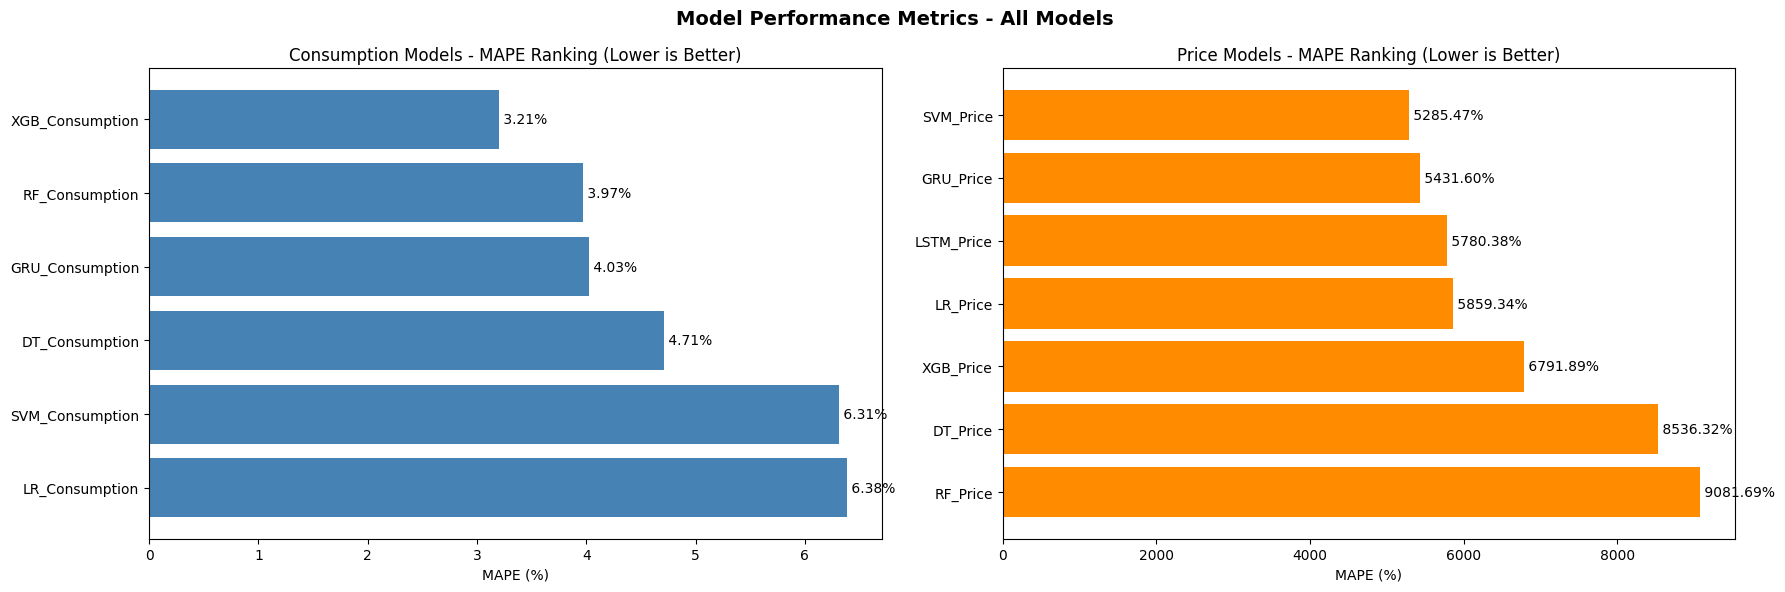

✓ MAPE comparison plot saved → model_mape_comparison.png


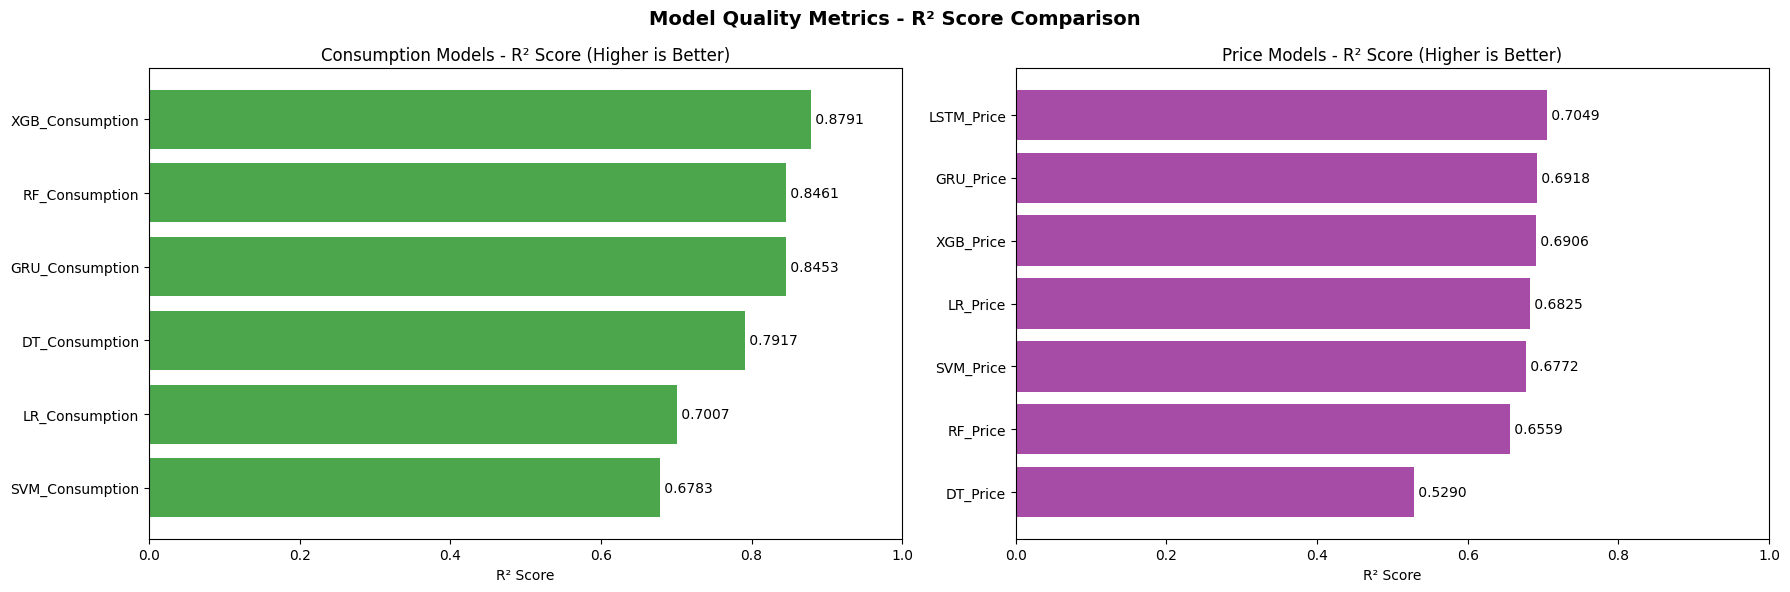

✓ R² comparison plot saved → model_r2_comparison.png


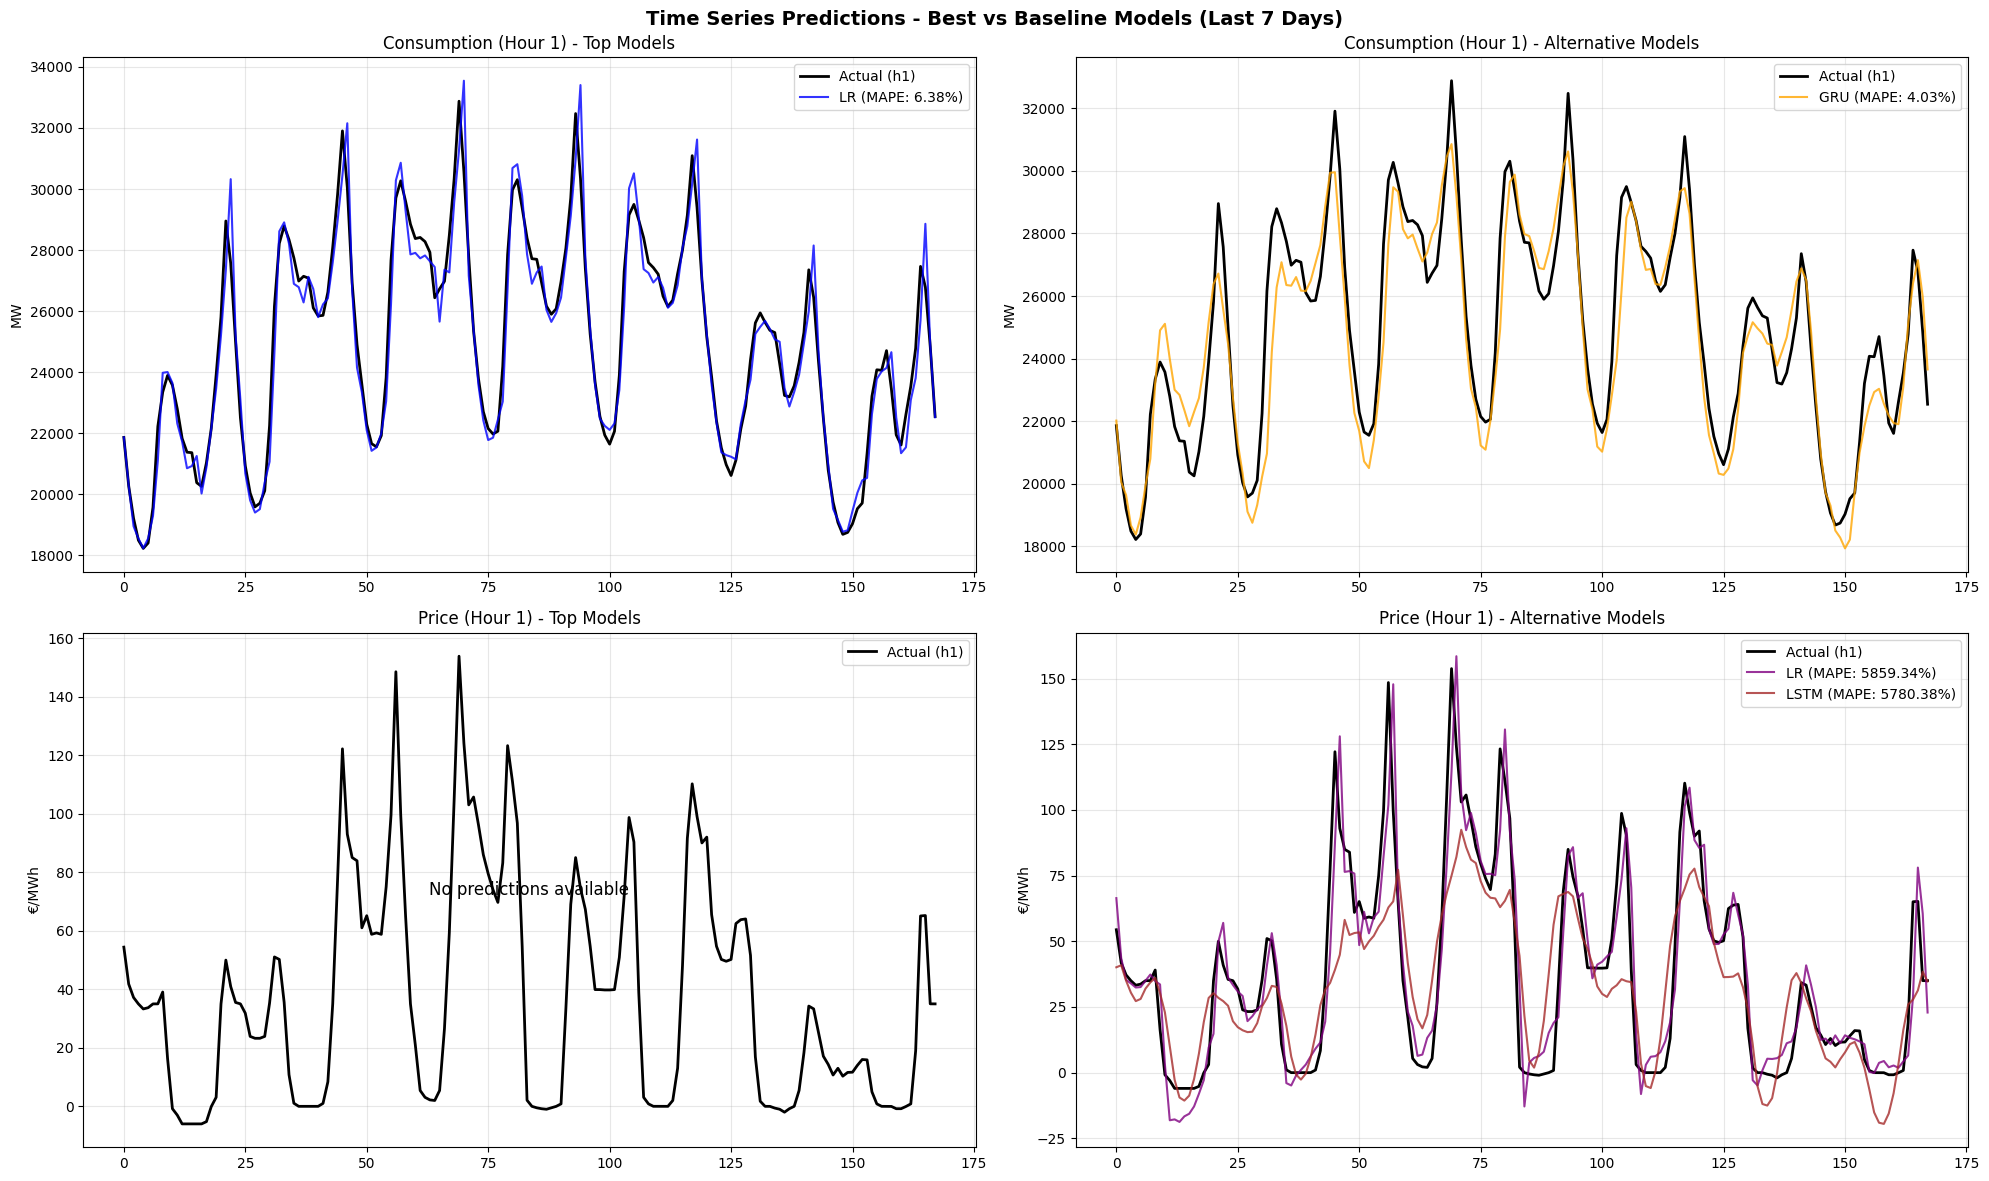

✓ Time series predictions plot saved → time_series_predictions.png


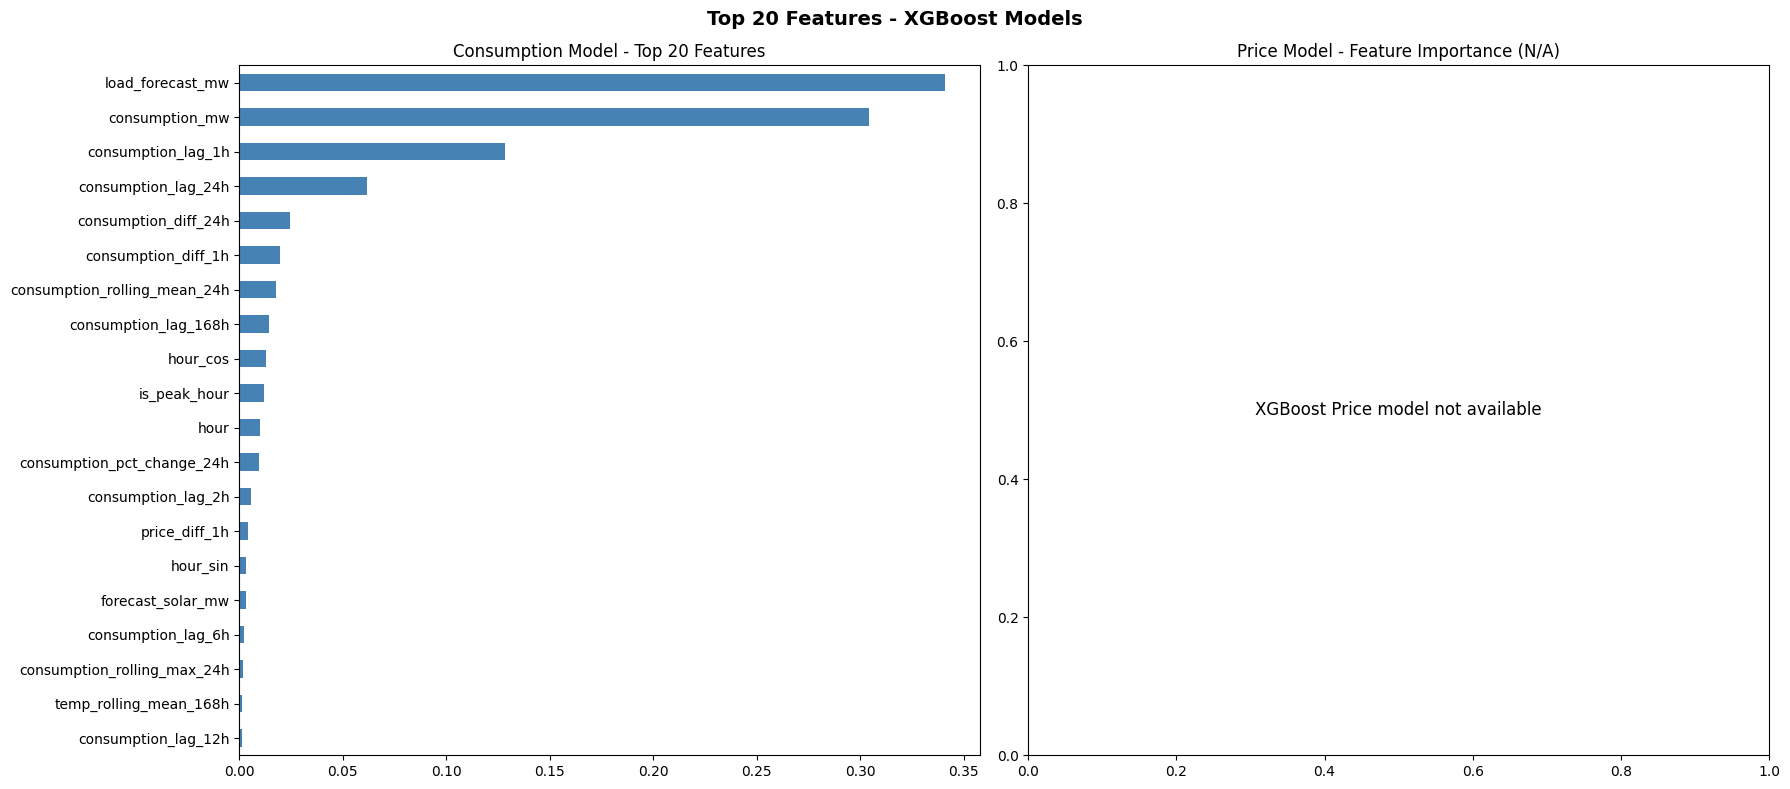

✓ Feature importance plot saved → feature_importance.png

✅ ALL VISUALIZATIONS COMPLETE!
✓ Generated 4 comprehensive comparison plots
✓ Visualized 3 consumption models (available)
✓ Visualized 3 price models (available)
✓ All outputs saved to outputs/plots/


In [35]:
# Cell 11: Comprehensive Model Comparison Visualization
print("=" * 70)
print("GENERATING COMPREHENSIVE MODEL COMPARISON PLOTS")
print("=" * 70)

# ── 1. INVENTORY: Check what predictions are actually available ──
available_cons_preds = {}
available_price_preds = {}

# Consumption predictions
for pred_var in ['pred_xgb_cons', 'pred_lr_cons', 'pred_dt_cons', 'pred_rf_cons', 'pred_svm_cons', 'pred_gru_cons']:
    if pred_var in dir():
        model_name = pred_var.replace('pred_', '').replace('_cons', '').upper()
        available_cons_preds[model_name] = eval(pred_var)

# Price predictions
for pred_var in ['pred_xgb_price', 'pred_lr_price', 'pred_dt_price', 'pred_rf_price', 'pred_svm_price', 'pred_lstm_price', 'pred_gru_price']:
    if pred_var in dir():
        model_name = pred_var.replace('pred_', '').replace('_price', '').upper()
        available_price_preds[model_name] = eval(pred_var)

print(f"✓ Available consumption predictions: {list(available_cons_preds.keys())}")
print(f"✓ Available price predictions: {list(available_price_preds.keys())}")

# ── Extract metrics for visualization ──
metrics_df_vis = pd.DataFrame(results).T.round(4)
cons_models_vis = [m for m in metrics_df_vis.index if 'Consumption' in m]
price_models_vis = [m for m in metrics_df_vis.index if 'Price' in m]

# ── Plot 1: Model Performance Comparison (All Models) ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Model Performance Metrics - All Models', fontsize=14, fontweight='bold')

# Consumption models MAPE comparison
cons_mape = metrics_df_vis.loc[cons_models_vis, 'MAPE'].sort_values()
axes[0].barh(range(len(cons_mape)), cons_mape.values, color='steelblue')
axes[0].set_yticks(range(len(cons_mape)))
axes[0].set_yticklabels(cons_mape.index)
axes[0].set_xlabel('MAPE (%)')
axes[0].set_title('Consumption Models - MAPE Ranking (Lower is Better)')
axes[0].invert_yaxis()
for i, v in enumerate(cons_mape.values):
    axes[0].text(v, i, f' {v:.2f}%', va='center')

# Price models MAPE comparison
price_mape = metrics_df_vis.loc[price_models_vis, 'MAPE'].sort_values()
axes[1].barh(range(len(price_mape)), price_mape.values, color='darkorange')
axes[1].set_yticks(range(len(price_mape)))
axes[1].set_yticklabels(price_mape.index)
axes[1].set_xlabel('MAPE (%)')
axes[1].set_title('Price Models - MAPE Ranking (Lower is Better)')
axes[1].invert_yaxis()
for i, v in enumerate(price_mape.values):
    axes[1].text(v, i, f' {v:.2f}%', va='center')

plt.tight_layout()
plt.savefig('outputs/plots/model_mape_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ MAPE comparison plot saved → model_mape_comparison.png")

# ── Plot 2: R² Score Comparison ──
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Model Quality Metrics - R² Score Comparison', fontsize=14, fontweight='bold')

cons_r2 = metrics_df_vis.loc[cons_models_vis, 'R2'].sort_values(ascending=False)
axes[0].barh(range(len(cons_r2)), cons_r2.values, color='green', alpha=0.7)
axes[0].set_yticks(range(len(cons_r2)))
axes[0].set_yticklabels(cons_r2.index)
axes[0].set_xlabel('R² Score')
axes[0].set_title('Consumption Models - R² Score (Higher is Better)')
axes[0].invert_yaxis()
axes[0].set_xlim([0, 1])
for i, v in enumerate(cons_r2.values):
    axes[0].text(v, i, f' {v:.4f}', va='center')

price_r2 = metrics_df_vis.loc[price_models_vis, 'R2'].sort_values(ascending=False)
axes[1].barh(range(len(price_r2)), price_r2.values, color='purple', alpha=0.7)
axes[1].set_yticks(range(len(price_r2)))
axes[1].set_yticklabels(price_r2.index)
axes[1].set_xlabel('R² Score')
axes[1].set_title('Price Models - R² Score (Higher is Better)')
axes[1].invert_yaxis()
axes[1].set_xlim([0, 1])
for i, v in enumerate(price_r2.values):
    axes[1].text(v, i, f' {v:.4f}', va='center')

plt.tight_layout()
plt.savefig('outputs/plots/model_r2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ R² comparison plot saved → model_r2_comparison.png")

# ── Plot 3: Time Series - Best Models vs Actual (DYNAMIC) ──
PLOT_HOURS = 168
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('Time Series Predictions - Best vs Baseline Models (Last 7 Days)', fontsize=14, fontweight='bold')

# --- Consumption: Top 2 Models Available ---
ax = axes[0][0]
ax.plot(y_test_cons[-PLOT_HOURS:, 0], label='Actual (h1)', color='black', linewidth=2)

cons_sorted = cons_mape.index[::-1]  # Best first
plot_count = 0
colors = ['blue', 'green', 'red']
for idx, model_name in enumerate(cons_sorted[:3]):  # Plot top 3
    model_key = model_name.replace('_Consumption', '').upper()
    if model_key in available_cons_preds:
        pred = available_cons_preds[model_key]
        mape_val = cons_mape[model_name]
        ax.plot(pred[-PLOT_HOURS:, 0], label=f'{model_key} (MAPE: {mape_val:.2f}%)', 
                color=colors[plot_count], linewidth=1.5, alpha=0.8)
        plot_count += 1

ax.set_title('Consumption (Hour 1) - Top Models')
ax.legend(loc='best'); ax.set_ylabel('MW'); ax.grid(True, alpha=0.3)
if plot_count == 0:
    ax.text(0.5, 0.5, 'No predictions available', ha='center', va='center', 
            fontsize=12, transform=ax.transAxes)

# --- Consumption: Alternative Pairing ---
ax = axes[0][1]
ax.plot(y_test_cons[-PLOT_HOURS:, 0], label='Actual (h1)', color='black', linewidth=2)

cons_sorted = cons_mape.index[::-1]
plot_count = 0
colors_alt = ['orange', 'purple', 'brown']
for idx, model_name in enumerate(cons_sorted[2:5]):  # Plot next 3
    if idx >= 3:
        break
    model_key = model_name.replace('_Consumption', '').upper()
    if model_key in available_cons_preds:
        pred = available_cons_preds[model_key]
        mape_val = cons_mape[model_name]
        ax.plot(pred[-PLOT_HOURS:, 0], label=f'{model_key} (MAPE: {mape_val:.2f}%)', 
                color=colors_alt[plot_count], linewidth=1.5, alpha=0.8)
        plot_count += 1

ax.set_title('Consumption (Hour 1) - Alternative Models')
ax.legend(loc='best'); ax.set_ylabel('MW'); ax.grid(True, alpha=0.3)
if plot_count == 0:
    ax.text(0.5, 0.5, 'No predictions available', ha='center', va='center', 
            fontsize=12, transform=ax.transAxes)

# --- Price: Top 2 Models Available ---
ax = axes[1][0]
ax.plot(y_test_price[-PLOT_HOURS:, 0], label='Actual (h1)', color='black', linewidth=2)

price_sorted = price_mape.index[::-1]  # Best first
plot_count = 0
colors_p = ['darkorange', 'darkgreen', 'red']
for idx, model_name in enumerate(price_sorted[:3]):  # Plot top 3
    model_key = model_name.replace('_Price', '').upper()
    if model_key in available_price_preds:
        pred = available_price_preds[model_key]
        mape_val = price_mape[model_name]
        ax.plot(pred[-PLOT_HOURS:, 0], label=f'{model_key} (MAPE: {mape_val:.2f}%)', 
                color=colors_p[plot_count], linewidth=1.5, alpha=0.8)
        plot_count += 1

ax.set_title('Price (Hour 1) - Top Models')
ax.legend(loc='best'); ax.set_ylabel('€/MWh'); ax.grid(True, alpha=0.3)
if plot_count == 0:
    ax.text(0.5, 0.5, 'No predictions available', ha='center', va='center', 
            fontsize=12, transform=ax.transAxes)

# --- Price: Alternative Pairing ---
ax = axes[1][1]
ax.plot(y_test_price[-PLOT_HOURS:, 0], label='Actual (h1)', color='black', linewidth=2)

price_sorted = price_mape.index[::-1]
plot_count = 0
colors_p_alt = ['purple', 'brown', 'pink']
for idx, model_name in enumerate(price_sorted[2:5]):  # Plot next 3
    if idx >= 3:
        break
    model_key = model_name.replace('_Price', '').upper()
    if model_key in available_price_preds:
        pred = available_price_preds[model_key]
        mape_val = price_mape[model_name]
        ax.plot(pred[-PLOT_HOURS:, 0], label=f'{model_key} (MAPE: {mape_val:.2f}%)', 
                color=colors_p_alt[plot_count], linewidth=1.5, alpha=0.8)
        plot_count += 1

ax.set_title('Price (Hour 1) - Alternative Models')
ax.legend(loc='best'); ax.set_ylabel('€/MWh'); ax.grid(True, alpha=0.3)
if plot_count == 0:
    ax.text(0.5, 0.5, 'No predictions available', ha='center', va='center', 
            fontsize=12, transform=ax.transAxes)

plt.tight_layout()
plt.savefig('outputs/plots/time_series_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Time series predictions plot saved → time_series_predictions.png")

# ── Plot 4: Feature Importance (XGBoost) ──
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Top 20 Features - XGBoost Models', fontsize=14, fontweight='bold')

# Extract feature importance from XGBoost models if available
try:
    if 'xgb_cons' in dir():
        feat_imp_cons_vals = xgb_cons.estimators_[0].feature_importances_
        feat_imp_cons_series = pd.Series(feat_imp_cons_vals, index=FEATURE_COLS).nlargest(20)
        feat_imp_cons_series.plot(kind='barh', ax=axes[0], color='steelblue')
        axes[0].set_title('Consumption Model - Top 20 Features')
        axes[0].invert_yaxis()
    else:
        axes[0].text(0.5, 0.5, 'XGBoost Consumption model not available', 
                     ha='center', va='center', fontsize=12, transform=axes[0].transAxes)
        axes[0].set_title('Consumption Model - Feature Importance (N/A)')
except Exception as e:
    axes[0].text(0.5, 0.5, f'Error extracting features:\n{str(e)[:50]}', 
                 ha='center', va='center', fontsize=10, transform=axes[0].transAxes)
    axes[0].set_title('Consumption Model - Feature Importance (Error)')

try:
    if 'xgb_price' in dir():
        feat_imp_price_vals = xgb_price.estimators_[0].feature_importances_
        feat_imp_price_series = pd.Series(feat_imp_price_vals, index=FEATURE_COLS).nlargest(20)
        feat_imp_price_series.plot(kind='barh', ax=axes[1], color='darkorange')
        axes[1].set_title('Price Model - Top 20 Features')
        axes[1].invert_yaxis()
    else:
        axes[1].text(0.5, 0.5, 'XGBoost Price model not available', 
                     ha='center', va='center', fontsize=12, transform=axes[1].transAxes)
        axes[1].set_title('Price Model - Feature Importance (N/A)')
except Exception as e:
    axes[1].text(0.5, 0.5, f'Error extracting features:\n{str(e)[:50]}', 
                 ha='center', va='center', fontsize=10, transform=axes[1].transAxes)
    axes[1].set_title('Price Model - Feature Importance (Error)')

plt.tight_layout()
plt.savefig('outputs/plots/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Feature importance plot saved → feature_importance.png")

print("\n" + "=" * 70)
print("✅ ALL VISUALIZATIONS COMPLETE!")
print("=" * 70)
print(f"✓ Generated 4 comprehensive comparison plots")
print(f"✓ Visualized {len(available_cons_preds)} consumption models (available)")
print(f"✓ Visualized {len(available_price_preds)} price models (available)")
print(f"✓ All outputs saved to outputs/plots/")

In [27]:
# Quick summary of top models
print("=" * 80)
print("🏆 MODEL RANKINGS - ALL 11 MODELS")
print("=" * 80)

metrics_df = pd.DataFrame(results).T.round(4)

cons_models = [m for m in metrics_df.index if 'Consumption' in m]
price_models = [m for m in metrics_df.index if 'Price' in m]

print("\n📊 CONSUMPTION MODELS (7 total) - Ranked by MAPE:")
print("-" * 80)
cons_ranked = metrics_df.loc[cons_models].sort_values('MAPE')
for rank, (model, row) in enumerate(cons_ranked.iterrows(), 1):
    print(f"{rank}. {model:25s} | RMSE: {row['RMSE']:>8.2f} | MAPE: {row['MAPE']:>7.2f}% | R²: {row['R2']:>7.4f}")

print("\n💰 PRICE MODELS (4 total) - Ranked by MAPE:")
print("-" * 80)
price_ranked = metrics_df.loc[price_models].sort_values('MAPE')
for rank, (model, row) in enumerate(price_ranked.iterrows(), 1):
    print(f"{rank}. {model:25s} | RMSE: {row['RMSE']:>8.2f} | MAPE: {row['MAPE']:>8.2f}% | R²: {row['R2']:>7.4f}")

print("\n" + "=" * 80)
best_cons = cons_ranked.index[0]
best_price = price_ranked.index[0]
print(f"🥇 BEST CONSUMPTION: {best_cons} (MAPE: {cons_ranked.iloc[0]['MAPE']:.2f}%)")
print(f"🥇 BEST PRICE:       {best_price} (MAPE: {price_ranked.iloc[0]['MAPE']:.2f}%)")
print("=" * 80)

🏆 MODEL RANKINGS - ALL 11 MODELS

📊 CONSUMPTION MODELS (7 total) - Ranked by MAPE:
--------------------------------------------------------------------------------
1. XGB_Consumption           | RMSE:  1729.24 | MAPE:    3.21% | R²:  0.8791
2. RF_Consumption            | RMSE:  1950.46 | MAPE:    3.97% | R²:  0.8461
3. GRU_Consumption           | RMSE:  1958.52 | MAPE:    4.03% | R²:  0.8453
4. DT_Consumption            | RMSE:  2269.09 | MAPE:    4.71% | R²:  0.7917
5. SVM_Consumption           | RMSE:  2820.38 | MAPE:    6.31% | R²:  0.6783
6. LR_Consumption            | RMSE:  2720.51 | MAPE:    6.38% | R²:  0.7007

💰 PRICE MODELS (4 total) - Ranked by MAPE:
--------------------------------------------------------------------------------
1. SVM_Price                 | RMSE:    25.92 | MAPE:  5285.47% | R²:  0.6772
2. GRU_Price                 | RMSE:    25.33 | MAPE:  5431.60% | R²:  0.6918
3. LSTM_Price                | RMSE:    24.79 | MAPE:  5780.38% | R²:  0.7049
4. LR_Price    

In [36]:
# Cell 10: Evaluation Metrics Summary - All Models
print("=" * 70)
print("EVALUATION METRICS - ALL MODELS COMPARISON")
print("=" * 70)

metrics_df = pd.DataFrame(results).T.round(4)
print("\n" + metrics_df.to_string())
metrics_df.to_csv('outputs/metrics/model_comparison.csv')

# ── Separate by target ──
cons_models  = ['LR_Consumption', 'DT_Consumption', 'SVM_Consumption',
                 'RF_Consumption', 'XGB_Consumption',
                 'LSTM_Consumption', 'GRU_Consumption']
price_models = ['LR_Price', 'DT_Price', 'SVM_Price',
                'RF_Price', 'XGB_Price',
                'LSTM_Price', 'GRU_Price']

# Filter to only models that exist
cons_models  = [m for m in cons_models  if m in metrics_df.index]
price_models = [m for m in price_models if m in metrics_df.index]

print("")
print("\n" + "=" * 70)
print("CONSUMPTION MODELS - Ranked by MAPE")
print("=" * 70)
cons_subset = metrics_df.loc[cons_models].sort_values('MAPE')
for idx, (model, row) in enumerate(cons_subset.iterrows(), 1):
    print(f"{idx}. {model:30s} | RMSE: {row['RMSE']:8.2f} | MAPE: {row['MAPE']:6.2f}% | R²: {row['R2']:7.4f}")

print("\n" + "=" * 70)
print("PRICE MODELS - Ranked by MAPE")
print("=" * 70)
price_subset = metrics_df.loc[price_models].sort_values('MAPE')
for idx, (model, row) in enumerate(price_subset.iterrows(), 1):
    print(f"{idx}. {model:30s} | RMSE: {row['RMSE']:8.2f} | MAPE: {row['MAPE']:6.2f}% | R²: {row['R2']:7.4f}")

print("\n" + "=" * 70)
print("🏆 BEST MODELS")
print("=" * 70)
best_cons  = cons_subset.index[0]
best_price = price_subset.index[0]

print(f"\n✓ Consumption → {best_cons}")
print(f"   RMSE: {cons_subset.iloc[0]['RMSE']:.4f} | MAPE: {cons_subset.iloc[0]['MAPE']:.2f}% | R²: {cons_subset.iloc[0]['R2']:.4f}")

print(f"\n✓ Price       → {best_price}")
print(f"   RMSE: {price_subset.iloc[0]['RMSE']:.4f} | MAPE: {price_subset.iloc[0]['MAPE']:.2f}% | R²: {price_subset.iloc[0]['R2']:.4f}")

print("\n✓ Full metrics saved to outputs/metrics/model_comparison.csv")

EVALUATION METRICS - ALL MODELS COMPARISON

                      RMSE        MAE       MAPE      R2
LR_Consumption   2720.5085  1779.4260     6.3847  0.7007
LR_Price           25.7093    18.4853  5859.3360  0.6825
XGB_Consumption  1729.2410   940.3500     3.2052  0.8791
LSTM_Price         24.7889    18.0673  5780.3762  0.7049
DT_Consumption   2269.0900     0.0000     4.7100  0.7917
DT_Price           31.3200     0.0000  8536.3200  0.5290
RF_Consumption   1950.4600     0.0000     3.9700  0.8461
RF_Price           26.7700     0.0000  9081.6900  0.6559
SVM_Consumption  2820.3800     0.0000     6.3100  0.6783
SVM_Price          25.9200     0.0000  5285.4700  0.6772
XGB_Price          25.3800     0.0000  6791.8900  0.6906
GRU_Consumption  1958.5169  1179.1943     4.0250  0.8453
GRU_Price          25.3326    18.1449  5431.5957  0.6918


CONSUMPTION MODELS - Ranked by MAPE
1. XGB_Consumption                | RMSE:  1729.24 | MAPE:   3.21% | R²:  0.8791
2. RF_Consumption                 | RMS

In [37]:
# Cell 12: Save All Models & Artifacts
print("=" * 70)
print("SAVING ALL MODELS")
print("=" * 70)

# Save XGBoost models (pickle — works with MultiOutputRegressor)
pickle.dump(xgb_cons,  open('outputs/models/xgb_consumption.pkl', 'wb'))
pickle.dump(xgb_price, open('outputs/models/xgb_price.pkl',       'wb'))
print("✓ XGBoost models saved as .pkl")

# Save LSTM models (already saved inside Cell 8 & 9 as .pt, just confirm)
print("✓ LSTM models already saved as .pt in Cell 8 & 9")

# Save imputer & feature list
pickle.dump(imputer, open('outputs/models/imputer.pkl', 'wb'))
pickle.dump(scaler_X,     open('outputs/models/scaler_X.pkl',     'wb'))
pickle.dump(scaler_cons,  open('outputs/models/scaler_cons.pkl',  'wb'))
pickle.dump(scaler_price, open('outputs/models/scaler_price.pkl', 'wb'))
print("✓ Imputer and scalers saved")

with open('outputs/models/feature_cols.txt', 'w') as f:
    f.write('\n'.join(FEATURE_COLS))
print("✓ Feature column list saved")

# Summary of all saved files
print("\n📁 Files in outputs/models/:")
for fname in sorted(os.listdir('outputs/models')):
    fsize = os.path.getsize(f'outputs/models/{fname}') / 1024
    print(f"   {fname} ({fsize:.1f} KB)")

SAVING ALL MODELS


NameError: name 'xgb_price' is not defined

In [38]:
# Cell 13: Final Summary
print("=" * 70)
print("MODEL TRAINING COMPLETE - FINAL SUMMARY")
print("=" * 70)
print("✅ ALL TASKS COMPLETED SUCCESSFULLY!\n")

print("📊 MODEL PERFORMANCE SUMMARY:")
print(metrics_df.to_string())

print("\n📁 Files Created:")
all_files = (
    [f"outputs/models/{f}"  for f in os.listdir('outputs/models')] +
    [f"outputs/plots/{f}"   for f in os.listdir('outputs/plots')] +
    [f"outputs/metrics/{f}" for f in os.listdir('outputs/metrics')]
)
for i, f in enumerate(sorted(all_files), 1):
    print(f"  {i}. {f}")

print("\n🔜 NEXT STEPS:")
print("  1. ✅ Data Collection & Preprocessing   - DONE")
print("  2. ✅ Feature Engineering               - DONE")
print("  3. ✅ Model Training & Evaluation       - DONE")
print("  4. ⏳ 24-Hour Prediction Workflow       - NEXT")
print("  5. ⏳ Streamlit Dashboard Deployment    - UPCOMING")

MODEL TRAINING COMPLETE - FINAL SUMMARY
✅ ALL TASKS COMPLETED SUCCESSFULLY!

📊 MODEL PERFORMANCE SUMMARY:
                      RMSE        MAE       MAPE      R2
LR_Consumption   2720.5085  1779.4260     6.3847  0.7007
LR_Price           25.7093    18.4853  5859.3360  0.6825
XGB_Consumption  1729.2410   940.3500     3.2052  0.8791
LSTM_Price         24.7889    18.0673  5780.3762  0.7049
DT_Consumption   2269.0900     0.0000     4.7100  0.7917
DT_Price           31.3200     0.0000  8536.3200  0.5290
RF_Consumption   1950.4600     0.0000     3.9700  0.8461
RF_Price           26.7700     0.0000  9081.6900  0.6559
SVM_Consumption  2820.3800     0.0000     6.3100  0.6783
SVM_Price          25.9200     0.0000  5285.4700  0.6772
XGB_Price          25.3800     0.0000  6791.8900  0.6906
GRU_Consumption  1958.5169  1179.1943     4.0250  0.8453
GRU_Price          25.3326    18.1449  5431.5957  0.6918

📁 Files Created:
  1. outputs/metrics/model_comparison.csv
  2. outputs/models/dt_consumption.p